wrote /home/ubuntu/clean/bench360/ACL-IE-Energy/figures/acl_rq3_qwen_quant_batch_acc_labeled_all_energy_vrdu.pdf
  Qwen3-VL-4B (FP16)     EM=65.6%  0.0602 0.0272 0.0222 0.0196 0.0182 0.0178
  Qwen3-VL-4B (FP8)      EM=65.1%  0.0448 0.0237 0.0204 0.0188 0.0193 0.0220
  Qwen3-4B (FP16)        EM=57.2%  0.0461 0.0162 0.0111 0.0086 0.0072 0.0072
  Qwen3-4B (FP8)         EM=56.5%  0.0313 0.0114 0.0084 0.0066 0.0057 0.0056


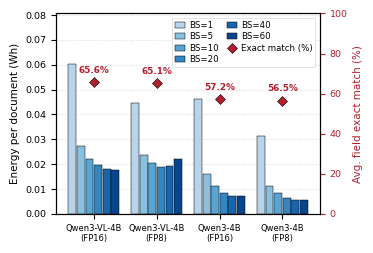

In [5]:
"""Regenerate the RQ3 quantization figure
(figures/acl_rq3_qwen_quant_batch_acc_labeled_all_energy_vrdu.pdf).

Fixes relative to visualization.ipynb:
  * One metric for every series. The previous figure read `avg_calculated_field_em`
    where that column existed (Qwen3-4B FP16 -> 58.8%) and fell back to
    `avg_field_em` where it did not (Qwen3-4B FP8 -> 56.5%), so the two bars of the
    quantization comparison were computed with different metrics. We use
    `avg_field_em` throughout, which is present in every run report and is the
    metric defined in the paper.
  * Compact legend inside the axes instead of a detached box below the plot.

Run from the repository root:  python visualizations/make_rq3_quant_acl.py
"""

import csv
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SRC = Path.cwd().parent
OUT = (SRC/ "ACL-IE-Energy" / "figures"
       / "acl_rq3_qwen_quant_batch_acc_labeled_all_energy_vrdu.pdf")

BATCHES = [1, 5, 10, 20, 40, 60]
METRIC = "avg_field_em"

# (display label, model_name, task)
SERIES = [
    ("Qwen3-VL-4B\n(FP16)", "Qwen3-VL-4B-Instruct", "vrdu_vision", False),
    ("Qwen3-VL-4B\n(FP8)", "Qwen3-VL-4B-Instruct", "vrdu_vision", True),
    ("Qwen3-4B\n(FP16)", "Qwen3-4B", "vrdu_tesseract", False),
    ("Qwen3-4B\n(FP8)", "Qwen3-4B", "vrdu_tesseract", True),
]


def load():
    """energy[series][bs] = Wh/doc ; em[series] = mean exact match over batch sizes."""
    energy = {s[0]: {} for s in SERIES}
    ems = {s[0]: [] for s in SERIES}
    for path in glob.glob(str(SRC / "*" / "run_report" / "*.csv")):
        for row in csv.DictReader(open(path)):
            quant = "quant" in row["backend"]
            for label, model, task, want_quant in SERIES:
                if row["model_name"] != model or row["task"] != task:
                    continue
                if quant != want_quant:
                    continue
                bs = int(row["batch_size"]) if row["scenario"] == "batch" else 1
                energy[label][bs] = float(row["total_energy_wh"]) / int(row["num_queries"])
                ems[label].append(float(row[METRIC]) * 100)
    return energy, {k: sum(v) / len(v) for k, v in ems.items() if v}


energy, em = load()

BLUES = plt.get_cmap("Blues")(np.linspace(0.30, 0.92, len(BATCHES)))

fig, ax = plt.subplots(figsize=(3.6, 2.4))
ax2 = ax.twinx()

group_w = 0.82
bar_w = group_w / len(BATCHES)
centers = np.arange(len(SERIES))

for j, bs in enumerate(BATCHES):
    xs = centers - group_w / 2 + bar_w * (j + 0.5)
    ys = [energy[s[0]].get(bs, np.nan) for s in SERIES]
    ax.bar(xs, ys, bar_w * 0.92, color=BLUES[j], edgecolor="black", linewidth=0.35,
           label=f"BS={bs}", zorder=3)

# Exact match as a marker per group, on the right axis.
acc = [em[s[0]] for s in SERIES]
ax2.plot(centers, acc, linestyle="none", marker="D", markersize=5.5,
         color="#b3202c", markeredgecolor="black", markeredgewidth=0.4,
         label="Exact match (%)", zorder=6)
for x, a in zip(centers, acc):
    ax2.annotate(f"{a:.1f}%", xy=(x, a), xytext=(0, 7), textcoords="offset points",
                 ha="center", fontsize=6.4, color="#b3202c", fontweight="bold", zorder=7)

ax.set_ylabel("Energy per document (Wh)", fontsize=7.5)
ax2.set_ylabel("Avg. field exact match (%)", fontsize=7.5, color="#b3202c")
ax.set_xticks(centers)
ax.set_xticklabels([s[0] for s in SERIES])
# Note: tick_params must come after set_xticklabels, otherwise it overrides the size.
ax.tick_params(axis="y", labelsize=6.8)
ax.tick_params(axis="x", labelsize=6.0)
ax2.tick_params(labelsize=6.8, colors="#b3202c")
ax.set_ylim(0, max(max(v.values()) for v in energy.values()) * 1.34)
ax2.set_ylim(0, 100)
ax.grid(True, axis="y", linestyle=":", alpha=0.45, zorder=0)
ax.set_axisbelow(True)

# Compact legend inside the plot: the upper-right region is empty because the
# tall bars sit on the left. Saves the detached legend box below the figure.
handles, labels = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax.legend(handles + h2, labels + l2, loc="upper right", ncol=2,
                fontsize=6.2, frameon=True, framealpha=0.92, borderpad=0.35,
                labelspacing=0.28, columnspacing=0.9, handlelength=1.2,
                handletextpad=0.45)
leg.get_frame().set_linewidth(0.4)
leg.set_zorder(8)

fig.tight_layout(pad=0.25)
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, bbox_inches="tight")
print(f"wrote {OUT}")

for label, *_ in SERIES:
    row = " ".join(f"{energy[label][b]:.4f}" for b in BATCHES if b in energy[label])
    print(f"  {label.replace(chr(10),' '):22s} EM={em[label]:.1f}%  {row}")